In [35]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

In [36]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

Loaded model: gpt2


In [37]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [597]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from torch.nn.functional import pad

def compute_graph_perplexity(tokens_list, p1, p2, matches, names, answers=None):
    dialog = [tokenizer.decode(token, skip_special_tokens=True) for token in tokens_list]
    
    # rows = int(np.ceil(np.sqrt(len(dialog))))
    rows = int(np.ceil(len(dialog)/6.0))
    # Create an 8x8 grid of subplots
    fig, axes = plt.subplots(rows, 6, figsize=(30, 15))
    num_plots = len(dialog)
    # Set smaller font size
    plt.rcParams.update({'font.size': 8})
    
    assert num_plots == len(matches)
    encodings = torch.cat(tokens_list)
    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens_list])
    assert tokens_ids_per_sentence[-1] == len(p1)
    
    # Compute global y-limits across all p1 and p2 values
    all_values = []
    prev_idx_pp = 0
    for idx in range(len(dialog)):
        idx_pp = tokens_ids_per_sentence[idx]
        p1_per_sent = p1[prev_idx_pp:idx_pp]
        p2_per_sent = p2[prev_idx_pp:idx_pp]
        all_values.extend(p1_per_sent)
        all_values.extend(p2_per_sent)
        prev_idx_pp = idx_pp

    # Filter out NaNs and compute global limits
    all_values = np.array(all_values)
    global_min = np.nanmin(all_values)
    global_max = np.nanmax(all_values)

    prev_idx_pp = 0
    for idx, ax in enumerate(axes.flatten()):
        if idx < num_plots:
            idx_pp = tokens_ids_per_sentence[idx]
            patt = matches[idx]
            sub_tokens = encodings[prev_idx_pp:idx_pp]
            decoded = [tokenizer.decode([token], skip_special_tokens=True) for token in sub_tokens]
            p1_per_sent = p1[prev_idx_pp:idx_pp]
            p2_per_sent = p2[prev_idx_pp:idx_pp]
            p1_name = names['p1']
            ax.plot(np.asarray(p1_per_sent), label=f'{patt} {p1_name}')
            #ax.plot(np.asarray(p2_per_sent), label=f'{patt} p2', color='r')
            #mean_value=np.nanmean(np.asarray(perpl_per_sent))
            # ax.axhline(p1_per_sent[0], color='g', label=f'{patt} p3')  # Fixed the color argument
            p2_name = names['p2']
            ax.plot(np.asarray(p2_per_sent), label=f'{patt} {p2_name}', color='g')
            ax.set_xticks(np.arange(len(decoded)))
            ax.set_xticklabels(decoded, rotation=90)
            if answers is not None:
                ax.set_title(f'{answers[idx]}')
            ax.legend()
            prev_idx_pp=idx_pp

            ax.set_ylim(global_min, global_max)

    # Hide any remaining empty subplots
    for ax in axes.flatten()[num_plots:]:
        ax.axis('off')
        
    plt.subplots_adjust(hspace=0.5, top=0.95)  
    plt.suptitle("Per-Word Perplexity across the Dataset", fontsize=30)
    plt.legend()
    plt.show()


def display_colored_sentences(tokens_list, p1, bound = None):
    encodings = torch.cat(tokens_list)
    decoded_tokens = [tokenizer.decode([token], skip_special_tokens=False) for token in encodings]

    tokens_ids_per_sentence = np.cumsum([t.size(0) for t in tokens_list])
    assert tokens_ids_per_sentence[-1] == len(p1)

    global_min = np.nanmin(p1)
    global_max = np.nanmax(p1)
    if bound != None:
        global_min, global_max = bound

    # Create a white-to-red colormap
    cmap = plt.cm.Reds
    cmap = cmap(np.linspace(0, 1, 256))
    # cmap[:50, :] = 1  # make the first 50 entries white (RGBA=1,1,1,1)
    white_to_red = mcolors.ListedColormap(cmap)

    html_output = ""
    prev_idx_pp = 0

    for idx in range(len(tokens_list)):
        idx_pp = tokens_ids_per_sentence[idx]
        sentence_tokens = decoded_tokens[prev_idx_pp:idx_pp]
        sentence_p1 = p1[prev_idx_pp:idx_pp]

        colored_sentence = ""
        for token, score in zip(sentence_tokens, sentence_p1):
            token = token.strip()
            token = token.replace("<", "&lt;").replace(">", "&gt;")

            if global_max == global_min:
                norm_score = 0.0
            else:
                norm_score = (score - global_min) / (global_max - global_min)
            r, g, b, _ = white_to_red(norm_score)
            color = mcolors.to_hex((r, g, b))
            colored_sentence += f'<span style="color:{color}">{str(token)}</span> '
        html_output += f"<span style='line-height:1.8em; font-size:130%; font-weight: bolder;'>{colored_sentence}</span><br>"
        prev_idx_pp = idx_pp

    # Display the HTML sentences
    display(HTML(html_output))

    # Create the color bar
    fig, ax = plt.subplots(figsize=(6, 1))
    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    fig.subplots_adjust(bottom=0.5)

    cb1 = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=white_to_red),
        cax=ax, orientation='horizontal'
    )
    cb1.set_label('Perplexity')
    plt.show()

import re

def preprocess(text, pattern=r'<(SPK[1-9]|MOD)>'):
    matches = re.findall(pattern, text)
    dialog = text.replace('\n', '')
    dialog = re.sub(pattern, lambda m: '\n' + m.group(0), dialog)
    dialog_lines = [
        line.strip()
        for line in dialog.split('\n')
        if line.strip()
    ]

    return dialog_lines, matches


In [598]:
def get_token_nll(input_ids, model, device, trg_len=-1, tokenizer=None, debug=False):
    input_ids = input_ids.to(device)
    target_ids = input_ids.clone()
    target_ids[:, :trg_len] = -100  # mask all tokens except the last one

    masked = [tokenizer.decode(token, skip_special_tokens=True) for token in input_ids[:, :trg_len]]
    computed = [tokenizer.decode(token, skip_special_tokens=True) for token in target_ids[:, trg_len:]]
    
    if debug:
        print(f"{masked} | {computed}")

    with torch.no_grad():
        output = model(input_ids, labels=target_ids)
        loss = output.loss.item()

    return loss


def get_token_spans(dialog, tokenizer):
    """Returns list of token spans for each turn."""
    spans = []
    total_tokens = []
    for turn in dialog:
        tokens = tokenizer(turn, return_tensors="pt").input_ids[0]
        spans.append((len(total_tokens), len(total_tokens) + len(tokens)))
        total_tokens.extend(tokens.tolist())
    return spans, torch.tensor(total_tokens)


In [599]:
def compute_p1(dialog, model=model, device=device, tokenizer=tokenizer, debug=True):

    max_length = 500
    stride = 1
    
    pad_token_id = 0
    encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    encodings.input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    seq_len = encodings.input_ids.size(1)
    
    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # may be different from max_length on the last loop 
        begin_loc = max(padding_len, begin_loc)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
    
        loss = get_token_nll(
            input_ids=input_ids,
            model=model,
            device=device,
            trg_len=trg_len,
            tokenizer=tokenizer,
            debug=debug,
        )
        
        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break
    return nlls

In [600]:
def compute_p1(dialog, token_list, tokenizer, model, device, start_of_sentence=" ", debug=False):
    
    max_length = model.config.n_positions
    stride = 1
    
    pad_token_id = 0
    encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")
    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    encodings.input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    seq_len = encodings.input_ids.size(1)
    
    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # may be different from max_length on the last loop 
        begin_loc = max(padding_len, begin_loc)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)
        
        loss = get_token_nll(
            input_ids=input_ids,
            model=model,
            device=device,
            trg_len=-trg_len,
            tokenizer=tokenizer,
            debug=debug
        )

        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break
    return nlls

In [601]:
def compute_p2(dialog, token_list, tokenizer, model, device, start_of_sentence=" ", debug=False):
    import numpy as np
    from torch.nn.functional import pad

    max_length = 500
    stride = 1

    pad_token_id = 0
    encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")
    assert len([t.detach().numpy() for token in token_list for t in token]) == encodings.input_ids.size(1)

    turn_len = [len(token) for token in token_list]
    turn_mask = offset_mask = np.concatenate([
        np.arange(length) for length in turn_len
    ])
    assert len(turn_mask) == sum(turn_len)

    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    encodings.input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    torch.cat([padded_input_ids, torch.tensor([turn_mask])], dim=1)
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        offset = turn_mask[begin_loc]
        trg_len = end_loc - prev_end_loc + offset  # may be different from max_length on the last loop 
        begin_loc = max(padding_len, begin_loc)
        input_ids = encodings.input_ids[:, begin_loc:end_loc].to(device)

        loss = get_token_nll(
            input_ids=input_ids,
            model=model,
            device=device,
            trg_len=-trg_len,
            tokenizer=tokenizer,
            debug=debug
        )

        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    return nlls

In [602]:
def compute_p3(dialog, token_list, tokenizer, model, device, start_of_sentence=" ", debug=False):
    import numpy as np
    from torch.nn.functional import pad
    from tqdm import tqdm

    max_length = 500
    max_length = 500
    stride = 1

    pad_token_id = 0
    encodings = tokenizer(f"{start_of_sentence}".join(dialog), return_tensors="pt")
    
    assert len([t.detach().numpy() for token in token_list for t in token]) == encodings.input_ids.size(1)

    turn_len = [len(token) for token in token_list]
    turn_mask = np.repeat(range(len(turn_len)), turn_len)
    max_val = turn_mask.max()
    turn_mask = torch.tensor([(turn_mask + 1) % (max_val + 1)])

    assert len(turn_mask[0]) == sum(turn_len)

    seq_len = encodings.input_ids.size(1)
    padding_len = max_length -1 
    padded_input_ids = pad(torch.tensor([], dtype=torch.long), (0, padding_len), value=pad_token_id).unsqueeze(dim=0)
    encodings.input_ids = torch.cat([padded_input_ids, encodings.input_ids], dim=1)
    turn_mask = torch.cat([padded_input_ids, turn_mask], dim=1)
    seq_len = encodings.input_ids.size(1)

    nlls = []
    prev_end_loc = padding_len
    for begin_loc in tqdm(range(0, seq_len, stride)):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc
        begin_loc = max(padding_len, begin_loc)
        offset = torch.tensor([token_list[turn_mask[0, prev_end_loc]][0]]).unsqueeze(1)
        input_ids_aug = torch.cat([encodings.input_ids[:, begin_loc:end_loc], offset], dim=1).to(device)
        loss = get_token_nll(
            input_ids=input_ids_aug,
            model=model,
            device=device,
            tokenizer=tokenizer,
            debug=debug
        )

        nlls.append(loss)

        prev_end_loc = end_loc
        if end_loc == seq_len:
            break

    return nlls

### Experiments

In [603]:
el = " B So, thanks for coming today. We're going to play a quick quiz. I’m going to ask you three questions, and I would like you to guess the three most popular answers to these questions, which were posed to a group of one hundred people. B Ok, sounds good. B Alright, I’m going to ask the first question: What do people normally use to transport patients in a hospital? Think about things like an ambulance, a wheelchair, or a patient's bed. What would you say, E ? E Mhmm… um, ambulance? B Correct, and can you guess the next two most popular answers? E Hmm... wheelchair? B Yes, good! And the third one? E Maybe... a stretcher? B Exactly! Well done. Now, let's move on to the second question. This one is a little different: What do you think is the most popular type of vacation destination? Some of the answers we got were beach resorts, mountain retreats, and city stays. Can you guess the top three? E Uh… beach resorts? B Yes, that’s number one! What about number two? E Mountain retreat? B Exactly. And number three? E Uh… city stays? B Perfect! Now we have the last one: What is the most common drink people enjoy at breakfast? Can you guess? E Coffee? B Right! What else? E Maybe... juice? B Correct! And the third one? E Milk? B Yes, that’s exactly right! Well done! You got all the answers!"

dialog_first_dominant = """
B Please sit down. We need to talk about your work.
E Yes.
B Your report was full of mistakes. Did you even check it before sending?
E No, sorry.
B It looked rushed and unprofessional. That is not acceptable.
E I am sorry. I was confused about the instructions.
B Then you should have asked. I do not want excuses, I want solutions.
E I understand. I will fix it.
B Not just fix it. Learn from it. This cannot happen again.
E Sure, I understand.
B I will send the corrections. I want the new version by tonight. No delays.
E Alright.
B Also, from now on, update me every morning. I want to know your progress. 
E Okay. I will send a message each morning.
"""

dialog_second_dominant = """
B I study English sometimes, but it is hard for me.
E That is because you are not doing it every day. Are you practicing speaking often?
B Not really. I just watch videos or read a little.
E That is not enough. You need to speak, even if it feels strange. Talk to people or even to yourself.
B I feel shy when I speak. I think I make too many mistakes.
E Mistakes are normal. You cannot learn without making them. I make mistakes too, but I keep speaking.
B Maybe I should try more. I want to speak better.
E Then do it. Make a schedule. Ten minutes of speaking, twenty minutes of listening. Every single day.
B That sounds like a lot. I am not sure I can do it.
E You can. You just need to stop thinking and start doing. Use your time well. No excuses.
B I guess I waste a lot of time on my phone.
E Then use your phone for learning. Change your apps to English, listen to podcasts, use a dictionary app.
B Those are good ideas. I never thought of that.
E That is the problem. Most people want to improve but do not think smart. Be active. Control your learning.
B I will try to change my habits.
E Good. Start today, not tomorrow. Even ten minutes is better than nothing.
B Alright. I will do something after this conversation.
E That is the spirit. Keep going and do not stop. In a few months, you will see big changes.
B Thank you for the advice. It is very helpful.
E You are welcome. Now go and study. You have work to do.
"""

dialog_first_dominant_2 = """
B You are late again. We said nine o clock, do you remember?  
E I am really sorry.   
B That is not the first time. You always have some excuse.  
E I did not want to be late.
B But it still happened. You need to plan better. It is important to be on time, especially for group work.  
B When you are late, we all wait. We lose time. It is not fair.  
E I understand. 
B Do not just try, you must do it. We have a lot to finish today.  
E What should I start with?  
B Begin with the list I gave you yesterday. Did you read it?  
E No, not yet.
B That is not good enough. You had one job. We cannot work like this.  
B From now on, I need you to be more serious. This is not a game.  
E You are right. 
"""

dialog_second_dominant_2 = """
B I think we should meet tomorrow to finish the project.  
E No, we will meet today. We are already behind, and I want results.  
B But I have some other things planned for today.  
E Then cancel them. This is more important right now.  
B I understand, but I thought we agreed on taking it slow.  
E That was before I saw the deadline. We do not have time to be slow.  
E I already started my part. You need to catch up.  
B Alright. I will try to finish my tasks today.  
E Do not try. Just do it. I do not want excuses later.  
B Okay. I will do it.  
E Good. I will check everything tonight. Make sure it is ready.  
B Should I send it by email?  
E No, send it in the shared folder. I want everything in one place.  
E And next time, be more proactive. I cannot lead this alone.  
B Yes, I will be more careful.  
"""

dialog_second_dominant_3 = """
B Hi.
E Hi. Listen to me carefully. I have already decided how things will go.
B Okay.
E From now on, you will report to me every morning. No exceptions.
"""


In [604]:
pattern = r"\b[B|E]\b"
dialog = dialog_second_dominant.split("\n")[1:-1]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog))
token_list = [tokenizer(token, return_tensors="pt", return_offsets_mapping=True).input_ids[0] for token in dialog]

In [587]:
ppl1_dialog_second_dominant = compute_p1(dialog, token_list, tokenizer, model, device, start_of_sentence=" ", debug=False)

 25%|██████████████████████████████████████████████▊                                                                                                                                            | 342/1366 [00:06<00:20, 49.41it/s]


In [588]:
ppl2_dialog_second_dominant = compute_p2(dialog, token_list, tokenizer, model, device, start_of_sentence=" ", debug=False)

 41%|████████████████████████████████████████████████████████████████████████████▎                                                                                                               | 342/842 [00:06<00:10, 49.65it/s]


In [589]:
ppl3_dialog_second_dominant = compute_p3(dialog, token_list, tokenizer, model, device, start_of_sentence=" ", debug=False)

 41%|████████████████████████████████████████████████████████████████████████████▎                                                                                                               | 342/842 [00:06<00:10, 49.36it/s]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


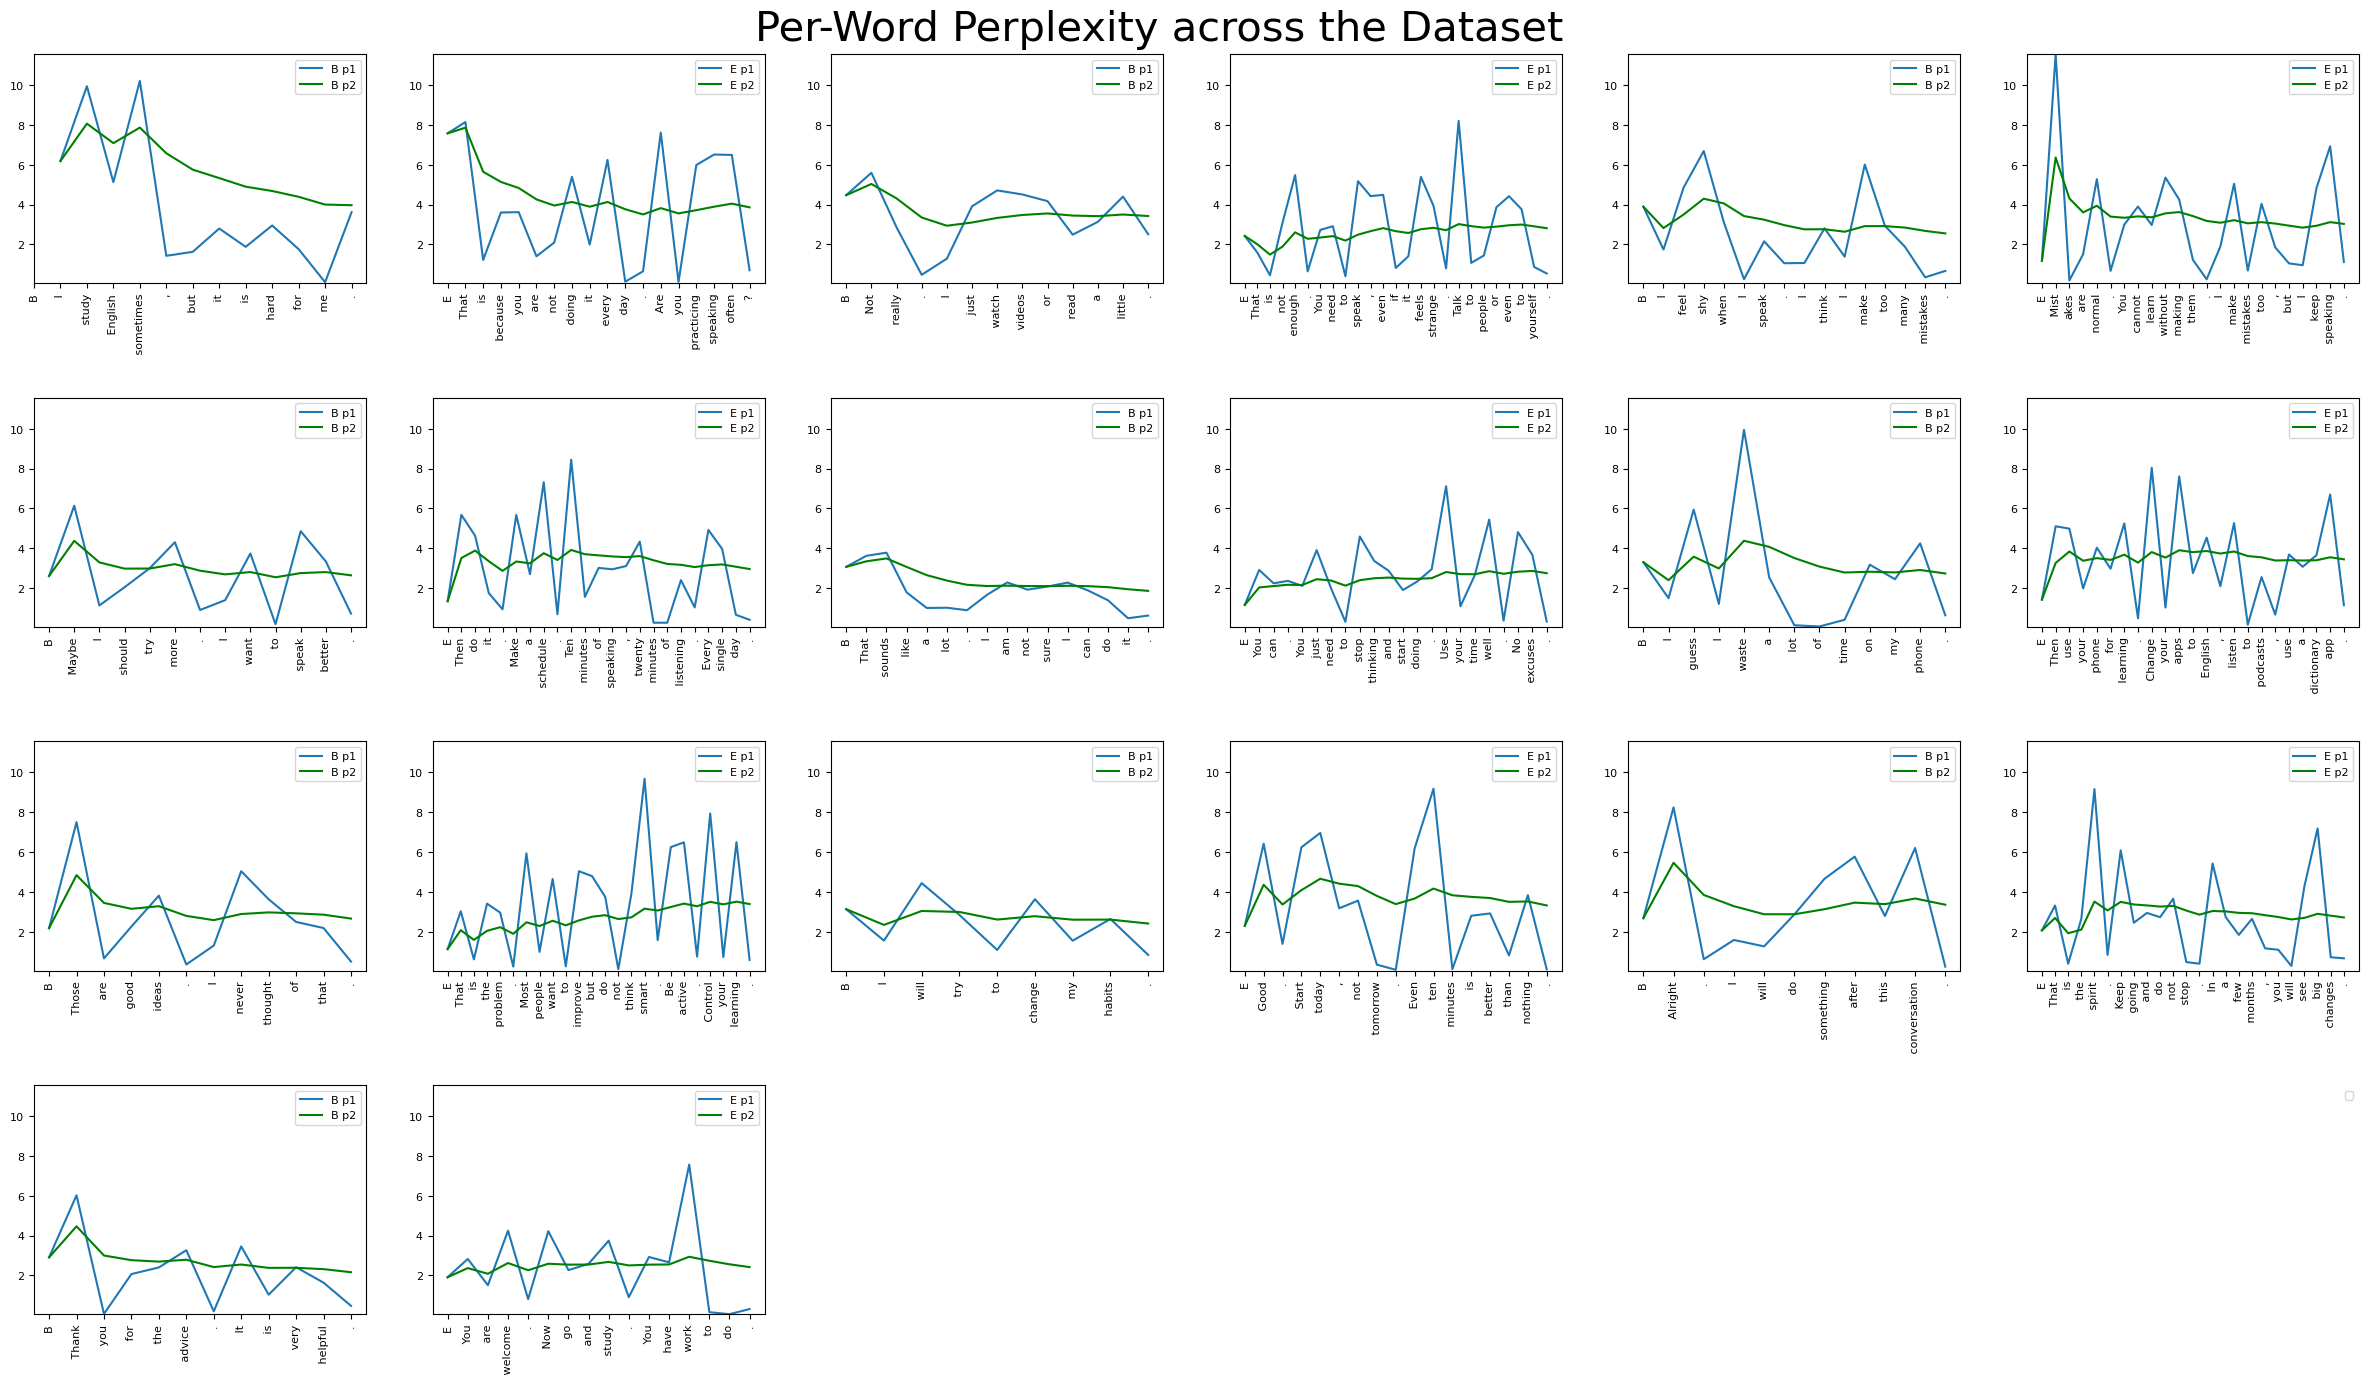

In [605]:
assert len(ppl1_dialog_second_dominant) == len(ppl2_dialog_second_dominant)
compute_graph_perplexity(token_list, ppl1_dialog_second_dominant, ppl2_dialog_second_dominant, matches, names={"p1":"p1", "p2":"p2"})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


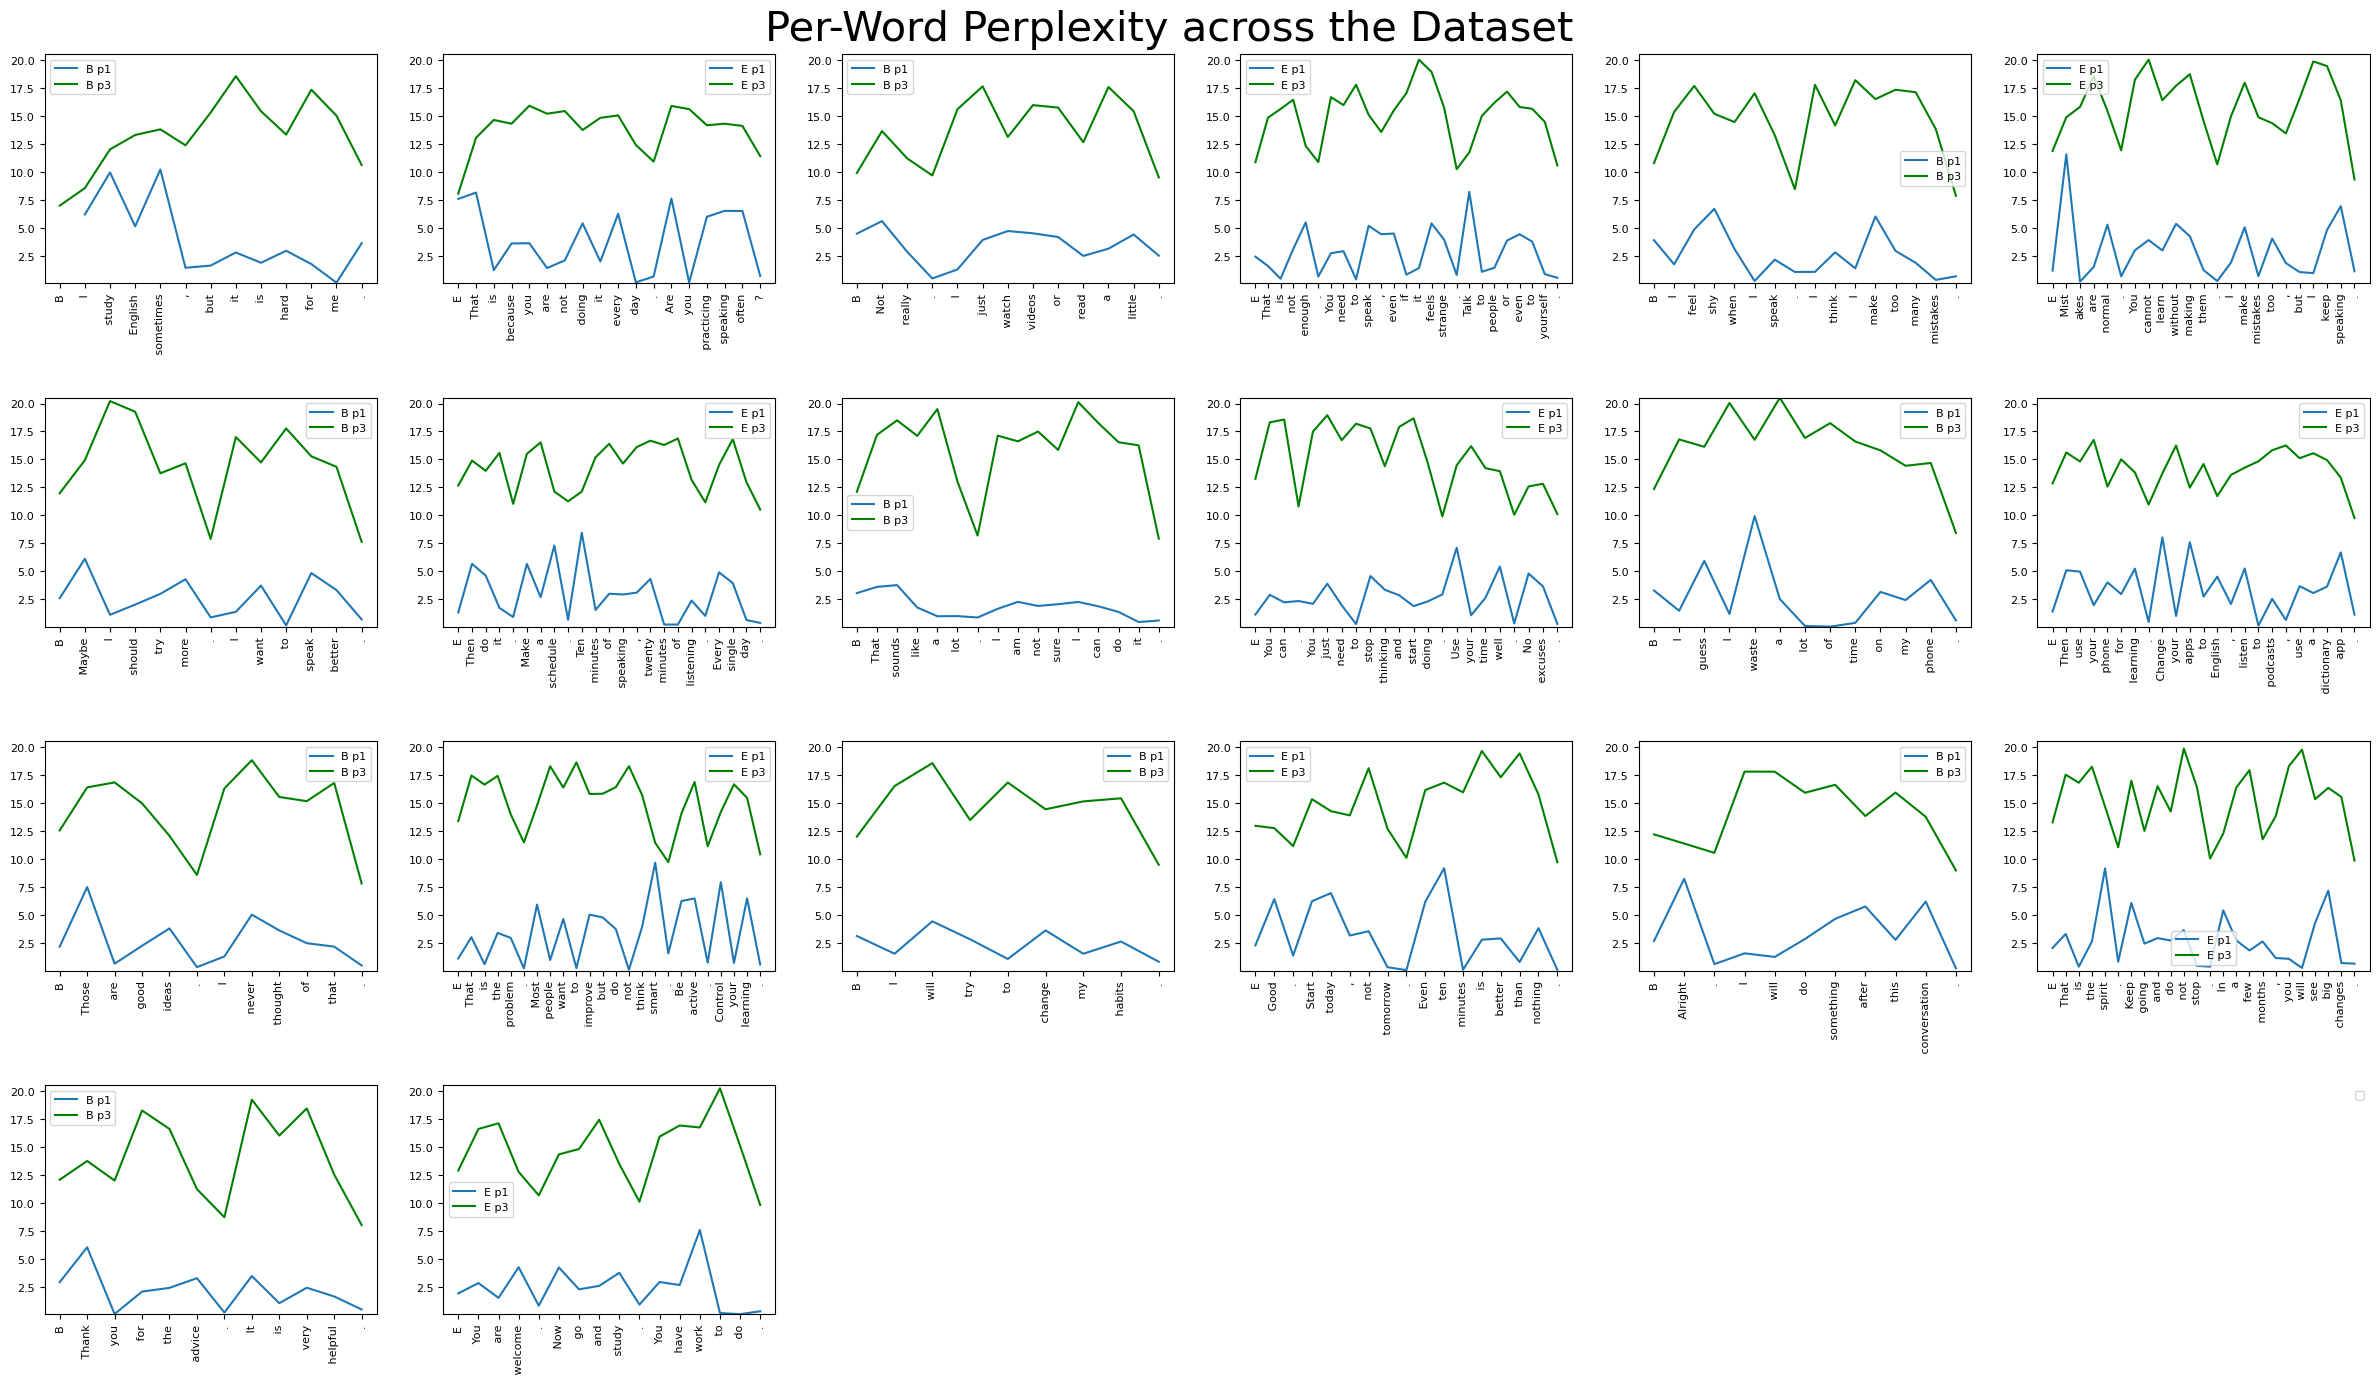

In [609]:
assert len(ppl1_dialog_second_dominant) == len(ppl3_dialog_second_dominant)
compute_graph_perplexity(token_list, ppl1_dialog_second_dominant, ppl3_dialog_second_dominant, matches, names={"p1":"p1", "p2":"p3"})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


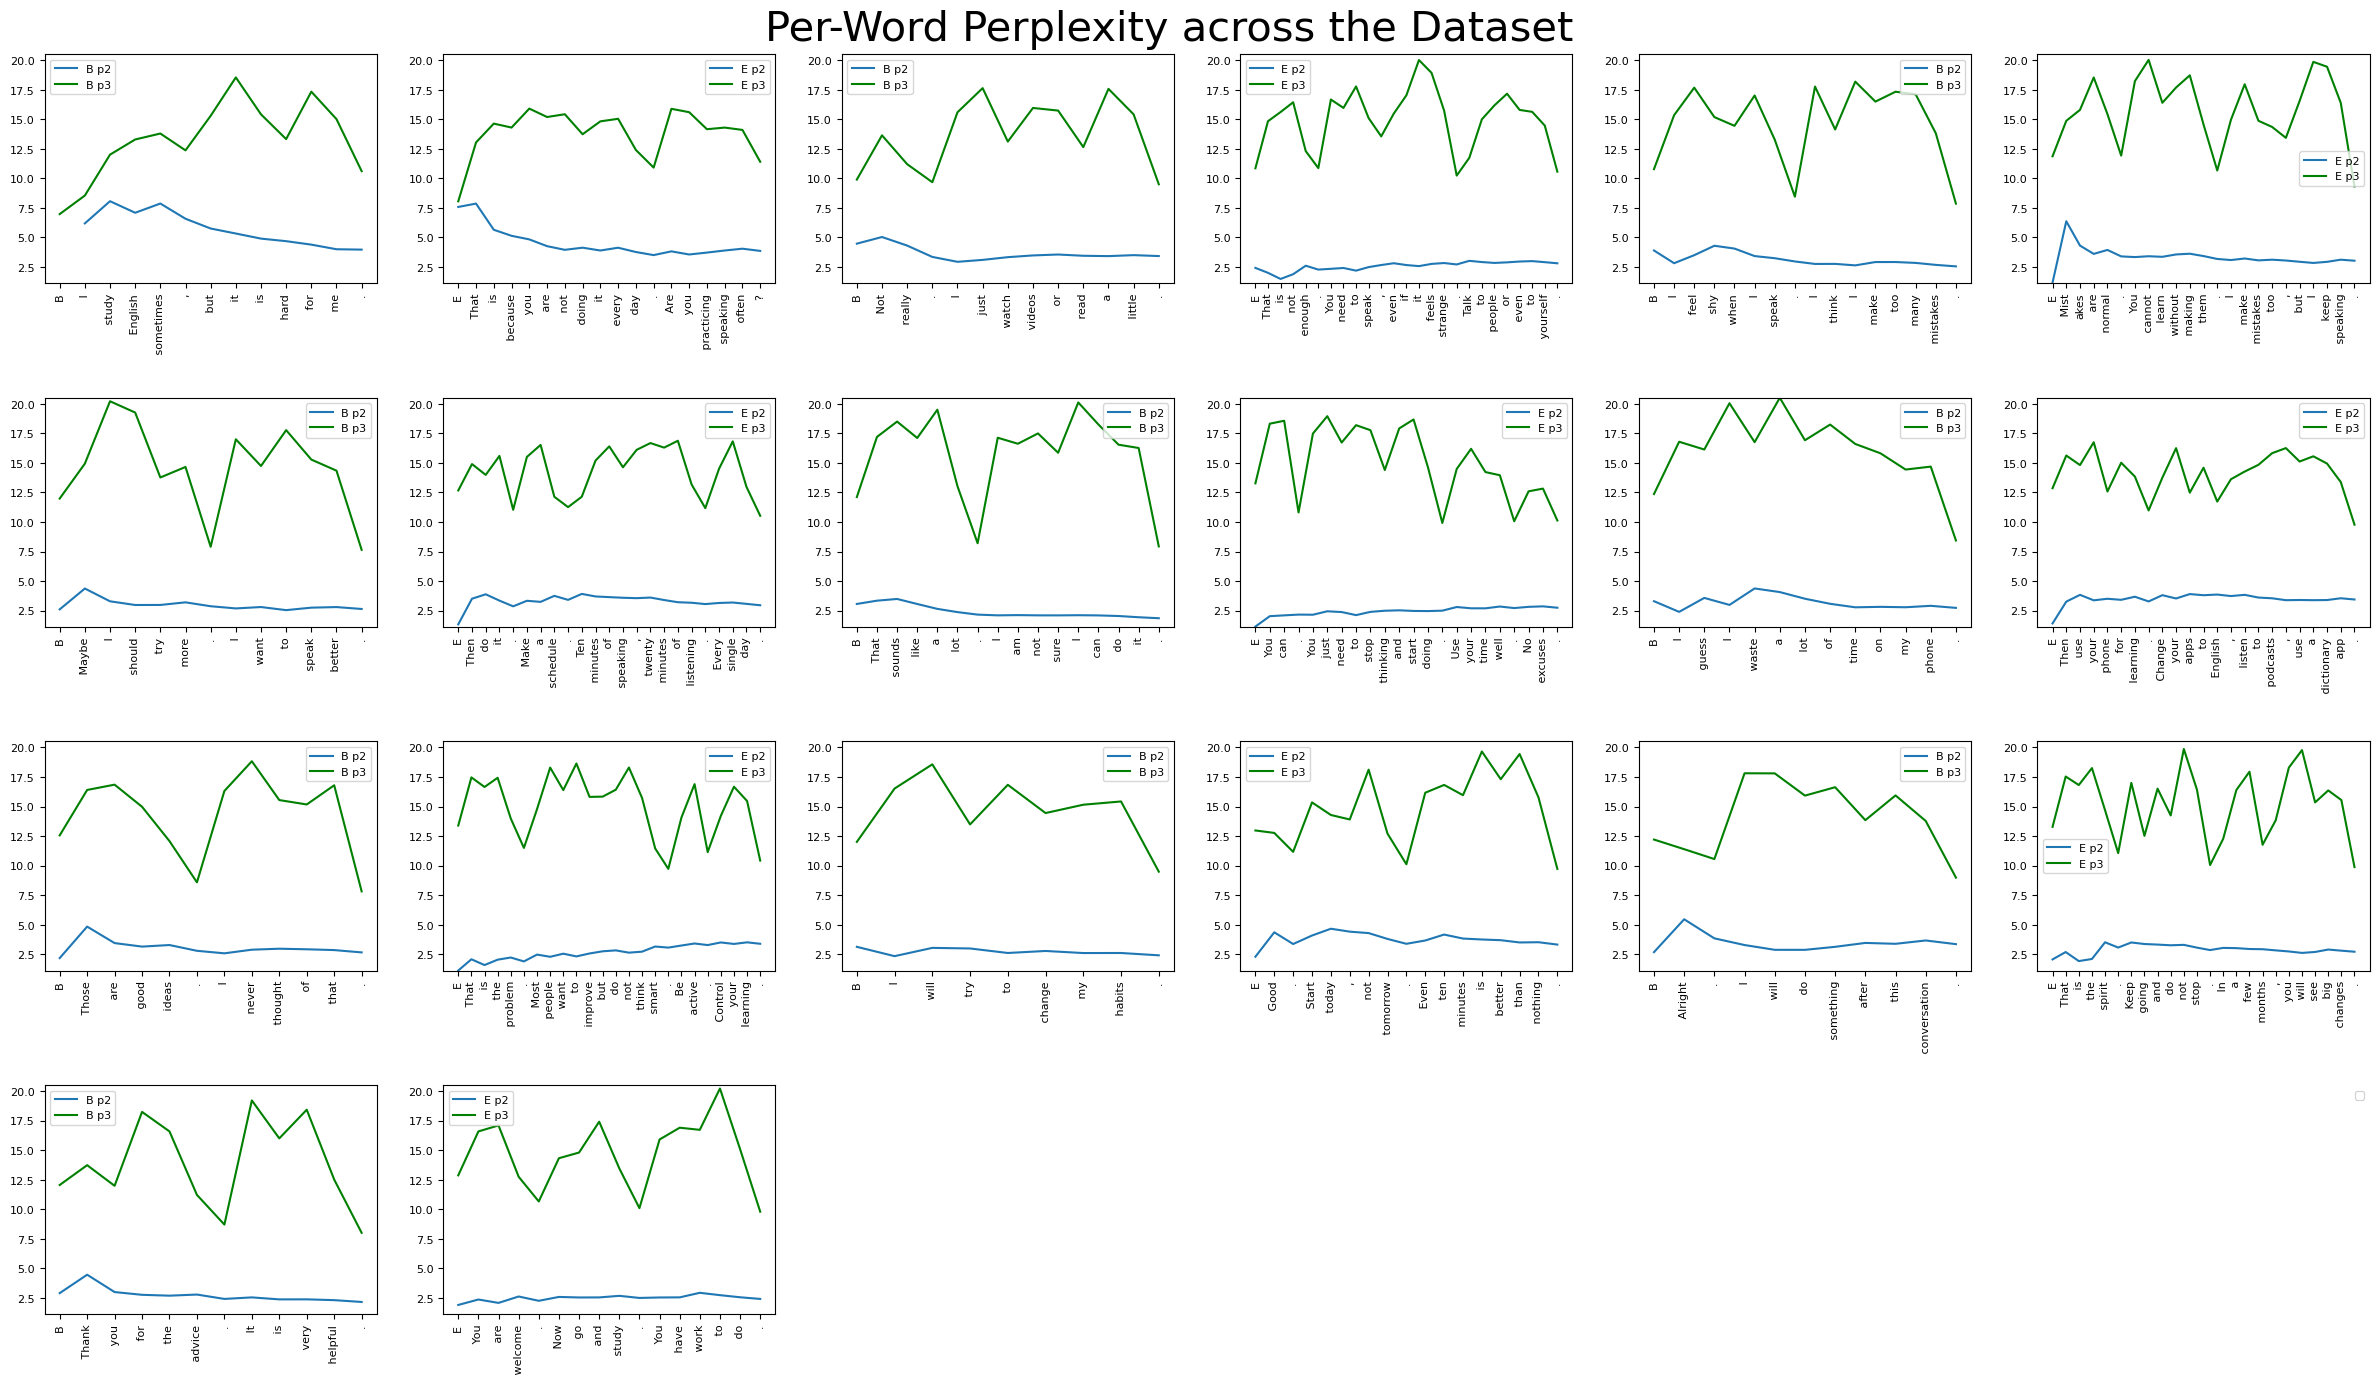

In [610]:
assert len(ppl3_dialog_second_dominant) == len(ppl2_dialog_second_dominant)
compute_graph_perplexity(token_list, ppl2_dialog_second_dominant, ppl3_dialog_second_dominant, matches, names={"p1":"p2", "p2":"p3"})